# TabFM, Tested Honestly

Google shipped a model that predicts on a spreadsheet it has never seen. No training, no tuning, one forward pass. In this notebook you run it yourself on a real table, race it against XGBoost and TabICL on the exact same split, and reproduce its hard limits first hand. Then you change the things that matter, the dtype, the split, the dataset, the class count, and watch what happens.

Quick honesty before we start. Zero-shot tabular prediction is not new. [TabPFN](https://github.com/PriorLabs/TabPFN) pioneered it and [TabICL](https://github.com/soda-inria/tabicl) pushed it further. TabFM is Google's entry into a race that already existed, trained on hundreds of millions of synthetic tables. Worth understanding, not worshipping.

- Episode video, [EPISODE VIDEO LINK]
- Code and skill, [github.com/SaschaHeyer/gen-ai-livestream/tree/main/tabfm](https://github.com/SaschaHeyer/gen-ai-livestream/tree/main/tabfm)
- Original announcement, [research.google blog](https://research.google/blog/introducing-tabfm-a-zero-shot-foundation-model-for-tabular-data/)

Everything below ran end to end before it was published, the outputs you see are from a real run, CPU only, no GPU anywhere. A TabFM fit and predict takes about a minute on CPU, each cell says what to expect.

## 1. Install and load

Imagine you hire a new analyst, and instead of studying your data for a week, they glance at your spreadsheet once and start predicting. That glance-and-go is what zero-shot tabular means, the technical name is in-context prediction. Before we can see it, we need the package and the weights.

> **Sharp edge, the install trap.** Do NOT `pip install tabfm` from PyPI. The PyPI 1.0.0 loader looks for `classification/pytorch_model.bin` while the Hugging Face repo ships `model.safetensors`, so `load()` dies with a FileNotFoundError after the download. Install from GitHub instead, that loader reads safetensors natively and pulls only the 6.6 GB checkpoint it needs rather than the full 13.2 GB.

TabFM needs Python 3.11 or newer. Colab currently ships a new enough Python, so you are fine here. Running locally, build a 3.12 venv first, a system Python 3.9 will not do.

In [1]:
# Installs take a couple of minutes. Later, the first load() call downloads the
# 6.6 GB classification checkpoint from Hugging Face, measured at ~6 minutes cold
# in prep. Colab will look idle during that download, it is not frozen.
%pip install -q "tabfm[pytorch] @ git+https://github.com/google-research/tabfm@633cd265f498e1d20c9625be0639f6305d8e2541" \
    torch==2.12.1 xgboost==3.3.0 tabicl==2.1.1 scikit-learn==1.9.0 \
    matplotlib==3.11.0 safetensors==0.8.0 huggingface-hub==1.22.0

Note: you may need to restart the kernel to use updated packages.


Two more sharp edges bite right at load time, so here they are before you hit them.

> **Sharp edge, the download backend.** The default Hugging Face Xet download backend crashed mid-download in prep (hf-xet Internal Writer Error). Setting `HF_HUB_DISABLE_XET=1` falls back to plain HTTP, which is reliable.

> **Sharp edge, dtype on CPU.** The loader defaults to bfloat16, which ran ~4.5x slower on CPU in prep, 220s instead of 49s for the exact same fit and predict. Pass `dtype=torch.float32` on CPU. On GPU, keep the bfloat16 default.

In [2]:
import os, time
os.environ["HF_HUB_DISABLE_XET"] = "1"   # Xet backend can crash mid-download, plain HTTP is reliable
import torch
from tabfm.src.pytorch import tabfm_v1_0_0
from tabfm import TabFMClassifier

t0 = time.time()
# dtype=float32 on CPU, the bfloat16 default is ~4.5x slower there
model = tabfm_v1_0_0.load(dtype=torch.float32)
print(f"model load: {time.time()-t0:.1f}s")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 21564.54it/s]

Loading weights from local directory


model load: 11.9s


**Your turn.** The first `load()` in a fresh runtime includes the 6.6 GB download, every load after that reads from the local cache. Run the cell below to see the warm load time. Then, if you are patient, change `torch.float32` to `torch.bfloat16` here and in the load cell above, re-run the hero cell in section 2, and watch the same computation take about 4.5x longer on CPU. That one line is the difference between 49 seconds and 220 seconds.

In [3]:
t0 = time.time()
model_again = tabfm_v1_0_0.load(dtype=torch.float32)   # try torch.bfloat16 here
print(f"warm load: {time.time()-t0:.1f}s")
del model_again   # one copy of a 6.6 GB model in memory is enough

warm load: 0.0s


## 2. The hero, fit and predict on a real table

Here is the whole magic in six lines. Load, wrap, fit, predict. And `fit` here does not train anything, it just stashes your table as context, that is the trick. `predict` is a single forward pass over your test rows with that context along for the ride.

We give it a dataset people know, wine, 178 rows, 13 numeric features, 3 classes, split the boring honest way. That stays comfortably inside the guardrails, at most 10 classes and up to 500 features.

Expect about a minute on CPU, and notice how anticlimactic it feels. No training bar crawls across the screen, you call predict and it is just done.

In [4]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_wine(return_X_y=True, as_frame=True)
print(f"dataset: wine, {X.shape[0]} rows, {X.shape[1]} features, {y.nunique()} classes")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

clf = TabFMClassifier(model=model)
t1 = time.time()
clf.fit(X_train, y_train)                # no training, stashes the table as context
preds = clf.predict(X_test)              # single forward pass, ~1 min on CPU
print(f"fit+predict: {time.time()-t1:.1f}s")

# predict() returns original labels in an object-dtype array, cast before scoring
print(f"TabFM zero-shot accuracy: {accuracy_score(y_test, preds.astype(int)):.4f}")

dataset: wine, 178 rows, 13 features, 3 classes


fit+predict: 41.5s
TabFM zero-shot accuracy: 1.0000


> **Sharp edge, the object-dtype labels.** `predict()` returns the original class labels in an object-dtype numpy array, and sklearn metrics refuse the mixed types. Cast first, `preds.astype(int)` for integer labels, or compare as strings.

**Your turn.** A perfect score on one split is one data point, not a verdict. The cell below reruns the exact same six lines on a different split, half the data held out and a different seed. Run it as given, then change `TEST_SIZE` and `RANDOM_STATE` to values of your own. When you are done playing, swap in your own table, the commented lines show where a CSV goes. Keep it inside the guardrails, at most 10 classes, up to 500 features, and remember every training row rides along as context, so start with hundreds of rows, not hundreds of thousands.

In [5]:
# YOUR TURN. Change the split, then try your own CSV.
TEST_SIZE = 0.5      # the hero run used 0.3, change me
RANDOM_STATE = 7     # the hero run used 42, change me too

X, y = load_wine(return_X_y=True, as_frame=True)
# your own table instead, uncomment and point at your file
# import pandas as pd
# X = pd.read_csv("your_table.csv")
# y = X.pop("your_label_column")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

clf = TabFMClassifier(model=model)
t1 = time.time()
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
print(f"fit+predict: {time.time()-t1:.1f}s")

# scoring as strings sidesteps the object-dtype edge for any label type
print(f"TabFM zero-shot accuracy: {accuracy_score(y_test.astype(str), preds.astype(str)):.4f}")

fit+predict: 41.5s
TabFM zero-shot accuracy: 0.9888


## 3. The honest benchmark, TabFM vs XGBoost vs TabICL

A big impressive number means nothing on its own, so let's race it against the classics on the exact same data and the exact same split. Plain XGBoost, the workhorse. TabICL, the much lighter zero-shot model that came before TabFM. And TabFM. Same metric for all three, plus the two numbers a leaderboard never shows you, how long each one took and how big its checkpoint is.

> **Sharp edge, two OpenMP runtimes.** XGBoost and PyTorch each bring their own OpenMP runtime on macOS, and loading both into one Python process segfaults or silently deadlocks. The benchmark below runs every model in its own subprocess for exactly that reason. Colab runs Linux, where a single process usually survives, but the isolation is the verified setup and it costs nothing, so it stays.

Expect a bit over a minute, almost all of it TabFM reloading its checkpoint and predicting inside its subprocess.

In [6]:
# The honest benchmark. Each model runs in its OWN subprocess, see the sharp
# edge above. TabFM reloads the (cached) checkpoint inside its subprocess.
import glob, json, subprocess, sys

BENCH = r"""
import json, os, sys, time
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

dataset, name = sys.argv[1], sys.argv[2]
if dataset == "wine":
    from sklearn.datasets import load_wine as load_ds
elif dataset == "breast_cancer":
    from sklearn.datasets import load_breast_cancer as load_ds

X, y = load_ds(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
if len(X_train) > 124:
    # keep TabFM cost comparable across datasets, every context row rides along
    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, train_size=124, random_state=42, stratify=y_train)
    X_test, y_test = X_test.iloc[:54], y_test.iloc[:54]

t0 = time.time()
if name == "XGBoost":
    from xgboost import XGBClassifier
    m = XGBClassifier(verbosity=0)
    m.fit(X_train, y_train); preds = m.predict(X_test)
elif name == "TabICL":
    from tabicl import TabICLClassifier
    m = TabICLClassifier()
    m.fit(X_train, y_train); preds = m.predict(X_test)
elif name == "TabFM":
    import torch
    from tabfm.src.pytorch import tabfm_v1_0_0
    from tabfm import TabFMClassifier
    model = tabfm_v1_0_0.load(dtype=torch.float32)
    m = TabFMClassifier(model=model)
    m.fit(X_train, y_train); preds = m.predict(X_test)
dt = time.time() - t0
if getattr(preds, "dtype", None) == object:
    preds = preds.astype(int)
print(json.dumps({"name": name, "acc": accuracy_score(y_test, preds), "sec": dt}))
"""


def cache_gb(pattern):
    return sum(os.path.getsize(f) for f in glob.glob(os.path.expanduser(pattern))
               if os.path.isfile(f) and not os.path.islink(f)) / 1e9


def run_race(dataset):
    results = {}
    for name in ["XGBoost", "TabICL", "TabFM"]:
        print(f"running {name} in its own process...", flush=True)
        out = subprocess.run([sys.executable, "-c", BENCH, dataset, name],
                             capture_output=True, text=True)
        line = [l for l in out.stdout.strip().splitlines() if l.startswith("{")][-1]
        r = json.loads(line)
        results[name] = (r["acc"], r["sec"])
        print(f'{name:8s} accuracy={r["acc"]:.4f}  fit+predict={r["sec"]:.1f}s', flush=True)
    sizes = {
        "XGBoost": 0.001,   # a trained booster is measured in megabytes
        "TabICL":  cache_gb("~/.cache/huggingface/hub/models--jingang--TabICL/blobs/*"),
        "TabFM":   cache_gb("~/.cache/huggingface/hub/models--google--tabfm-1.0.0-pytorch/blobs/*"),
    }
    print("checkpoint sizes GB:", {k: round(v, 3) for k, v in sizes.items()})
    return results, sizes


results, sizes = run_race("wine")

running XGBoost in its own process...


XGBoost  accuracy=1.0000  fit+predict=0.7s


running TabICL in its own process...


TabICL   accuracy=1.0000  fit+predict=2.1s


running TabFM in its own process...


TabFM    accuracy=1.0000  fit+predict=58.3s


checkpoint sizes GB: {'XGBoost': 0.001, 'TabICL': 0.11, 'TabFM': 13.149}


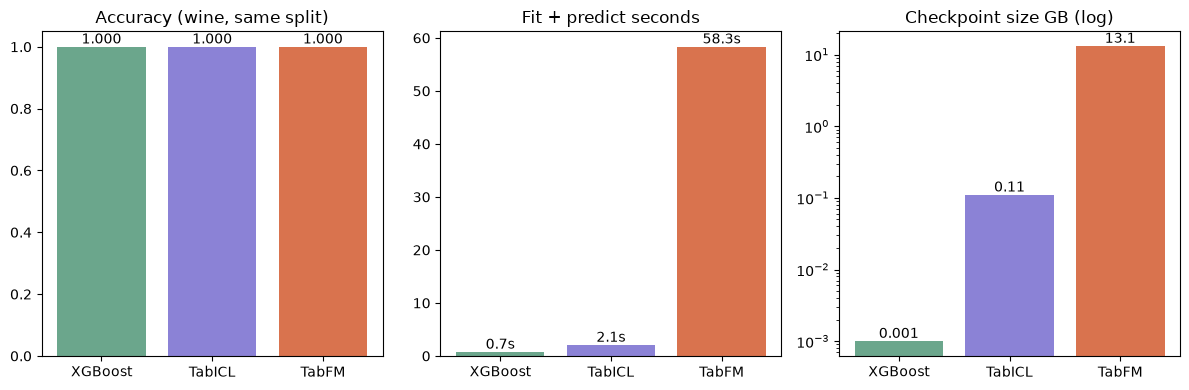

In [7]:
import matplotlib.pyplot as plt


def race_chart(results, sizes, dataset):
    names = list(results)
    accs  = [results[n][0] for n in names]
    times = [results[n][1] for n in names]
    szs   = [max(sizes[n], 0.001) for n in names]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, vals, title, fmt in [
        (axes[0], accs,  f"Accuracy ({dataset}, same split)", "{:.3f}"),
        (axes[1], times, "Fit + predict seconds",             "{:.1f}s"),
        (axes[2], szs,   "Checkpoint size GB (log)",          "{:.3g}"),
    ]:
        bars = ax.bar(names, vals, color=["#6BA68C", "#8B82D6", "#D9734E"])
        ax.set_title(title)
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, b.get_height(), fmt.format(v),
                    ha="center", va="bottom")
    axes[2].set_yscale("log")
    plt.tight_layout()
    plt.show()


race_chart(results, sizes, "wine")

Read it honestly. On wine all three models tie on accuracy, so the drama lives entirely in the other two panels. In the prep run TabFM paid 55 seconds and 13.1 GB of checkpoints for its score, TabICL paid 2.5 seconds and 0.11 GB, XGBoost paid under half a second and a model measured in megabytes. To be fair to TabFM, wine is an easy dataset, everything aces it, so this run cannot show whether the big model wins on harder data. That is exactly the takeaway, the leaderboard where TabFM shines is not your data, the only number that matters is the one on your own table.

**Your turn.** Same race, different table. The cell below runs breast cancer, 569 rows and 30 features, capped to the same 124 context rows so the TabFM cost stays comparable. Run it, read the three panels, then edit `BENCH` above to load your own CSV and race the three models on data that actually matters to you.

running XGBoost in its own process...


XGBoost  accuracy=0.9444  fit+predict=0.1s


running TabICL in its own process...


TabICL   accuracy=0.9630  fit+predict=2.3s


running TabFM in its own process...


TabFM    accuracy=0.9815  fit+predict=78.9s


checkpoint sizes GB: {'XGBoost': 0.001, 'TabICL': 0.11, 'TabFM': 13.149}


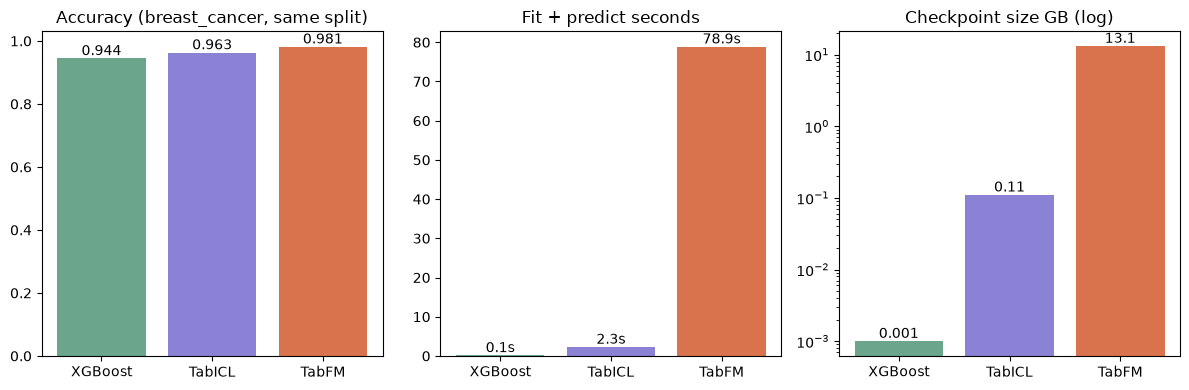

In [8]:
# YOUR TURN. Same race, different dataset. Then wire your own CSV into BENCH.
results_bc, sizes_bc = run_race("breast_cancer")
race_chart(results_bc, sizes_bc, "breast_cancer")

## 4. The hard limits, reproduced on purpose

The model card says classification supports at most 10 classes. A limit you have reproduced yourself is a limit you never forget, so let's hit it on purpose. We build a synthetic 11-class problem and watch the fit refuse.

This is also where the license deserves one honest sentence. The GitHub code is Apache 2.0, but the weights carry the TabFM Non-Commercial License v1.0, so read it before you build a product on them. And the announced BigQuery SQL integration is upcoming, not shipped, do not promise your boss a query today.

In [9]:
import numpy as np

rng = np.random.default_rng(0)
X_syn = rng.normal(size=(220, 5))
y_syn = np.arange(220) % 11          # 11 classes, one past the documented cap
clf = TabFMClassifier(model=model)
try:
    clf.fit(X_syn, y_syn)
    preds = clf.predict(X_syn[:10])
    print("UNEXPECTED: 11 classes fit and predicted without error")
except Exception as e:
    print(f"CONFIRMED, 11 classes rejected: {type(e).__name__}: {str(e)[:200]}")

CONFIRMED, 11 classes rejected: ValueError: The number of classes (11) exceeds the maximum number of classes (10) supported by the model.


**Your turn.** Now step back inside the fence. Change `N_CLASSES` below to 10 and the same code fits and predicts happily, change it back to 11 and you get the refusal you just saw. While you are here, this is also the knob for exploring the other limit, the model card says TabFM is optimized for up to 500 features, so try widening `N_FEATURES` and watch what happens to the runtime.

In [10]:
# YOUR TURN. 10 classes is the fence, step inside it and the model cooperates.
N_CLASSES = 10       # set back to 11 to see the refusal again
N_FEATURES = 5       # the model card says optimized for up to 500

X_syn = rng.normal(size=(220, N_FEATURES))
y_syn = np.arange(220) % N_CLASSES
clf = TabFMClassifier(model=model)
try:
    t1 = time.time()
    clf.fit(X_syn, y_syn)
    preds = clf.predict(X_syn[:10])
    print(f"{N_CLASSES} classes accepted, predicted {len(preds)} rows "
          f"in {time.time()-t1:.1f}s")
except Exception as e:
    print(f"rejected: {type(e).__name__}: {str(e)[:200]}")

10 classes accepted, predicted 10 rows in 46.0s


## Solutions

One worked answer per your-turn cell. Read them after you tried, not instead of trying.

**Section 1, the dtype experiment.** The changed line is `model = tabfm_v1_0_0.load(dtype=torch.bfloat16)`. In prep the identical wine fit and predict took 49.2s in float32 and about 220s in bfloat16 on CPU, roughly 4.5x slower, because CPUs emulate bfloat16 math they do not natively accelerate. On a GPU the default is the right choice and float32 would be the mistake.

**Section 2, the split experiment.** With `TEST_SIZE = 0.5` and `RANDOM_STATE = 7` the executed run above shows the score TabFM gets with only 89 context rows instead of 124. Wine is easy enough that the score barely moves across reasonable splits, which is itself the lesson, and the run gets faster as the context shrinks, because every context row rides along in the forward pass. For your own CSV the pattern is

```python
import pandas as pd
X = pd.read_csv("your_table.csv")
y = X.pop("your_label_column")
```

then the same split, fit, and predict. Score with `accuracy_score(y_test.astype(str), preds.astype(str))` so the object-dtype labels never bite you regardless of label type.

**Section 3, the dataset race.** The executed breast cancer run sits above. The shape of the answer is the point, whichever dataset you pick, all three models see the identical split, and you read accuracy, seconds, and gigabytes side by side. To race your own table, add a branch inside `BENCH` that does `X = pd.read_csv(...)` and `y = X.pop(...)`, keep the context cap if your table is large, and call `run_race("yours")`.

**Section 4, the limits.** With `N_CLASSES = 10` the fit is accepted and the 10 predictions come back, the executed cell above shows the timing. With 11 you get the same ValueError as the verified cell, the cap is architectural, not a warning. Widening `N_FEATURES` toward 500 keeps working but the forward pass grows with the table, which is the memory story from the episode, every training row and every feature rides along as context at inference time.

## Take it home

Everything here also ships as an installable skill for your coding agent. After installing, your agent knows the verified setup, the PyPI install trap, the CPU dtype fix, the download workaround, and the hard limits, and it can run this honest test on your own CSVs without rediscovering any of it.

```bash
npx skills add https://github.com/SaschaHeyer/gen-ai-livestream/tree/main/tabfm/skill
```

The full writeup with the reasoning behind every number lives in the article linked from the video description, and the episode itself is at [EPISODE VIDEO LINK].

If you take one thing home, take this. Do not migrate on a headline, benchmark the lighter model on your own data first, sometimes it is already doing the job. Tell me which model won on your table, I actually want to know. Connect on [LinkedIn](https://www.linkedin.com/in/saschaheyer/) and subscribe on [YouTube](https://www.youtube.com/@ml-engineer) for the next honest test, every Friday.